# Unit 4 — Hidden Markov models

The practice questions of this unit (21CSC305P). Every question below is self-contained: run any cell on its own. All questions use the Seattle daily weather data (`website/data/seattle_weather.csv`). Run the first cell before the others.

In [1]:
%config InlineBackend.figure_format = "svg"
import os
import sys
sys.path.insert(0, "website")          # plot style lives in website/weather.py
from weather import use_style
use_style()
if os.path.basename(os.getcwd()) != "website":
    os.chdir("website")                # so the programs find data/seattle_weather.csv

## Practice 1 — Implement HMM to predict the sequential data

The hidden state is whether a day is wet or dry. We pretend we cannot see it and only see the temperature range of the day (cloudy, rainy days change less). By counting on 2012–2014 we learn the start, transition and emission probabilities. Then the Viterbi algorithm guesses the most likely wet/dry sequence for 2015, and the transition probabilities forecast the next days.

Start probabilities:
state
dry    0.56
wet    0.44
Name: proportion, dtype: float64

Transition probabilities (row = today, column = tomorrow):
state   dry   wet
state            
dry    0.76  0.24
wet    0.31  0.69

Emission probabilities (row = state, column = what we see):
seen   small  medium  large
state                      
dry     0.11    0.35   0.54
wet     0.44    0.50   0.06

Viterbi accuracy on 2015: 0.737

Actual (rows) vs guessed (columns):
guess  dry  wet
state          
dry    159   62
wet     34  110

Day 1 -> P(wet) = 0.69
Day 2 -> P(wet) = 0.55
Day 3 -> P(wet) = 0.49
Day 4 -> P(wet) = 0.46
Day 5 -> P(wet) = 0.45


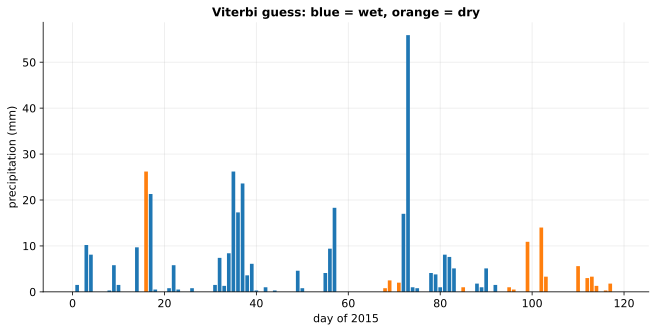

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("data/seattle_weather.csv")

# Hidden state: wet or dry
df["state"] = np.where(df["precipitation"] > 0, "wet", "dry")

# Observation: the temperature range of the day, as small / medium / large
df["temp_range"] = df["temp_max"] - df["temp_min"]
df["seen"] = pd.cut(df["temp_range"], bins=[-1, 5, 9, 100], labels=["small", "medium", "large"])

# Learn from 2012-2014, test on 2015
train = df[df["date"] < "2015-01-01"]
test = df[df["date"] >= "2015-01-01"].copy()
states = ["dry", "wet"]

# 1. Learn the HMM by counting
# Start probability: how often each state happens
start = train["state"].value_counts(normalize=True)
# Transition probability: P(tomorrow's state | today's state)
transition = pd.crosstab(train["state"], train["state"].shift(-1), normalize="index")
# Emission probability: P(what we see | state)
emission = pd.crosstab(train["state"], train["seen"], normalize="index")

print("Start probabilities:")
print(start.round(2))
print()
print("Transition probabilities (row = today, column = tomorrow):")
print(transition.round(2))
print()
print("Emission probabilities (row = state, column = what we see):")
print(emission.round(2))
print()


# 2. Viterbi: the most likely sequence of hidden states
def viterbi(seen):
    # prob[s] = probability of the best path so far that ends in state s
    # path[s] = that path
    prob = {}
    path = {}
    for s in states:
        prob[s] = start[s] * emission.loc[s, seen[0]]
        path[s] = [s]

    for day in range(1, len(seen)):
        new_prob = {}
        new_path = {}
        for s in states:
            # Which state yesterday leads to s with the highest probability?
            best_prev = "dry"
            best_value = 0
            for prev in states:
                value = prob[prev] * transition.loc[prev, s]
                if value > best_value:
                    best_value = value
                    best_prev = prev
            new_prob[s] = best_value * emission.loc[s, seen[day]]
            new_path[s] = path[best_prev] + [s]
        prob = new_prob
        path = new_path

    # Return the path that ends with the higher probability
    if prob["wet"] > prob["dry"]:
        return path["wet"]
    return path["dry"]


test["guess"] = viterbi(list(test["seen"]))
accuracy = (test["guess"] == test["state"]).mean()
print("Viterbi accuracy on 2015:", round(accuracy, 3))
print()
print("Actual (rows) vs guessed (columns):")
print(pd.crosstab(test["state"], test["guess"]))
print()

# 3. Forecast: suppose today is wet. How likely is a wet day in each of the next 5 days?
p = np.array([0.0, 1.0])   # [P(dry), P(wet)] today
for day in range(1, 6):
    p = p @ transition.values
    print("Day", day, "-> P(wet) =", round(p[1], 2))

# Plot: rain in the first 120 days of 2015, blue = HMM guessed wet
first = test.head(120)
colours = np.where(first["guess"] == "wet", "tab:blue", "tab:orange")
plt.figure(figsize=(9, 4.5))
plt.bar(range(120), first["precipitation"], color=colours)
plt.xlabel("day of 2015")
plt.ylabel("precipitation (mm)")
plt.title("Viterbi guess: blue = wet, orange = dry")
plt.show()